<a target="_blank" href="https://colab.research.google.com/github/lukebarousse/Python_Data_Analytics_Course/blob/main/4_Problems/2_11_Pandas Explode.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

In [3]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

## 🟨 Bar Plot of Top Skills for Cloud Engineers (2.11.1)

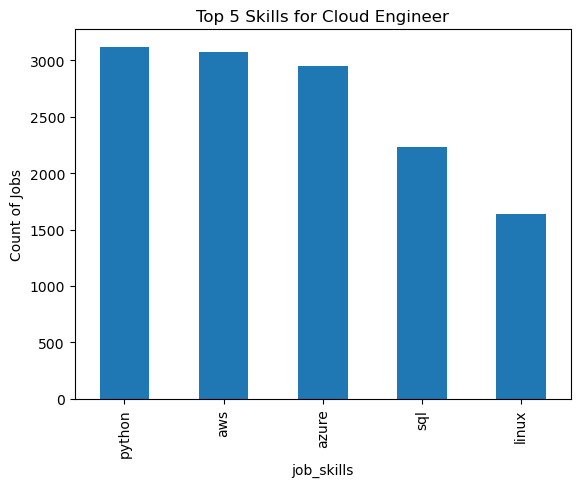

In [13]:
job = 'Cloud Engineer'

top_number = 5

df_explode = df.explode('job_skills')

df_cloud_eng = df_explode[df_explode['job_title_short'] == job]

df_plot = df_cloud_eng.pivot_table(index= 'job_skills', aggfunc= 'size').sort_values(ascending= False).head(top_number)

df_plot.plot(kind = 'bar')
plt.title(f"Top {top_number} Skills for {job}")
plt.ylabel('Count of Jobs')
plt.show()

---

## 🟨 Average Salary by Skill (2.11.2)

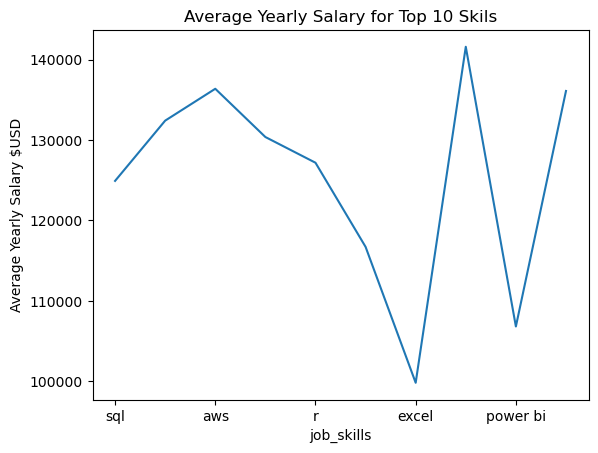

In [ ]:
top_skills = df_explode.job_skills.value_counts().sort_values(ascending= False).head(10).index.to_list() # calculated top skills by count


df_avg_salary = df_explode.dropna(subset= ['salary_year_avg']).pivot_table(index= 'job_skills', values='salary_year_avg', aggfunc= 'mean') # calculated avg salary by skills

df_avg_salary.loc[top_skills].plot(kind = 'line') # filtered avg salary pivot by top skills 
plt.title('Average Yearly Salary for Top 10 Skils')
plt.ylabel('Average Yearly Salary ($USD)')
plt.legend().set_visible(False)
plt.show()


---

## 🟥 Unique Skills Count (2.11.3)

In [ ]:
# Unique Skill count

df_explode.job_skills.value_counts()

job_skills
sql             384849
python          380909
aws             145381
azure           132527
r               130892
                 ...  
rubyon rails         1
visualbasic          1
msaccess             1
dingtalk             1
rocketchat           1
Name: count, Length: 252, dtype: int64

---